In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file_path = "..\\Data\\processed\\VNSGU_SEM4_All_Student_Results_Cleaned.csv"
df = pd.read_csv(file_path)


# Display basic info
print(df.head())
print(df.info())

   Seat Number                        Name  \
0         1007  AHIR VIRALKUMAR RAMESHBHAI   
1         1005       AHIR NILAY ARVINDBHAI   
2         1004    AHIR MITKUMAR SURESHBHAI   
3         1002      AHIR KRISH PRAMODKUMAR   
4         1006       AHIR TEJ PRAKASHKUMAR   

                                     College Name  Total Marks  SGPA Result  \
0  V.S. PATEL COLLEGE OF ARTS & SCIENCE, BILIMORA          266  4.82   PASS   
1  V.S. PATEL COLLEGE OF ARTS & SCIENCE, BILIMORA          306  5.73   PASS   
2  V.S. PATEL COLLEGE OF ARTS & SCIENCE, BILIMORA          333  5.91   PASS   
3  V.S. PATEL COLLEGE OF ARTS & SCIENCE, BILIMORA          297  5.27   PASS   
4  V.S. PATEL COLLEGE OF ARTS & SCIENCE, BILIMORA          325  5.82   PASS   

   JAVA_Ext  JAVA_Int  JAVA_Total  JAVA_Th_Ext  ...  OSS_Int  OSS_Total  \
0        19        22          41            9  ...       21         46   
1        21        24          45           11  ...       19         44   
2        26        24  

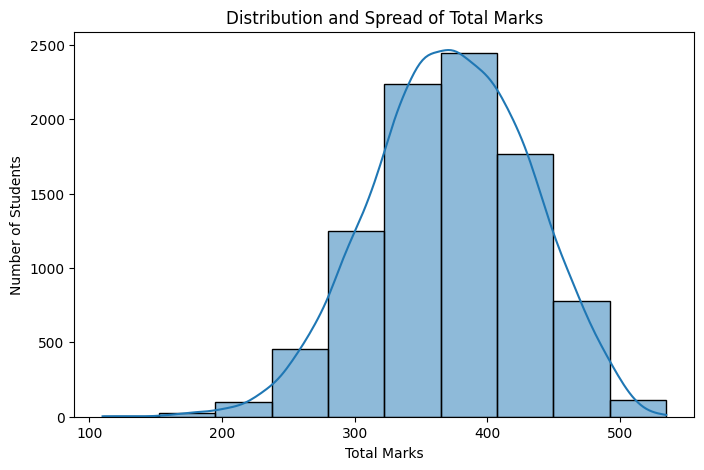

In [2]:
plt.figure(figsize=(8,5))
sns.histplot(df['Total Marks'], bins=10, kde=True)
plt.title("Distribution and Spread of Total Marks")
plt.xlabel("Total Marks")
plt.ylabel("Number of Students")
plt.show()

In [3]:
df.columns.to_list()

['Seat Number',
 'Name',
 'College Name',
 'Total Marks',
 'SGPA',
 'Result',
 'JAVA_Ext',
 'JAVA_Int',
 'JAVA_Total',
 'JAVA_Th_Ext',
 'JAVA_Th_Int',
 'JAVA_Pr_Ext',
 'JAVA_Pr_Int',
 'NET_Ext',
 'NET_Int',
 'NET_Total',
 'NET_Th_Ext',
 'NET_Th_Int',
 'NET_Pr_Ext',
 'NET_Pr_Int',
 'MAD_Ext',
 'MAD_Int',
 'MAD_Total',
 'MAD_Th_Ext',
 'MAD_Th_Int',
 'MAD_Pr_Ext',
 'MAD_Pr_Int',
 'IOT_Ext',
 'IOT_Int',
 'IOT_Total',
 'OSS_Ext',
 'OSS_Int',
 'OSS_Total',
 'CC_Ext',
 'CC_Int',
 'CC_Total',
 'BMP_Ext',
 'BMP_Int',
 'BMP_Total',
 'Course_Name',
 'Percentage']

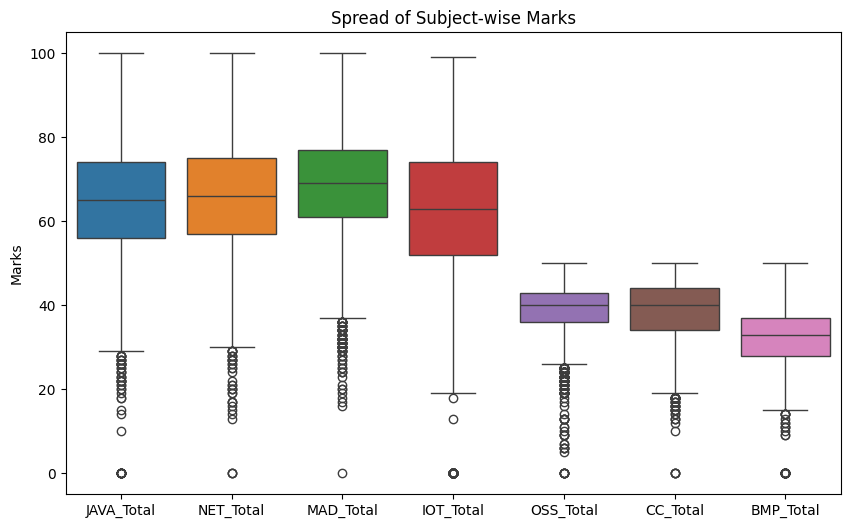

In [4]:
# plt.figure(figsize=(10,6))
# sns.boxplot(data=df[['AWD_Total','WFS_Total','.NET_Total','LOS_Total','NT_Total','CC_Total']])
# plt.title("Spread of Subject-wise Marks")
# plt.ylabel("Marks")
# plt.show()

plt.figure(figsize=(10,6))

sns.boxplot(data=df[[
    'JAVA_Total',
    'NET_Total',
    'MAD_Total',
    'IOT_Total',
    'OSS_Total',
    'CC_Total',
    'BMP_Total'
]])

plt.title("Spread of Subject-wise Marks")
plt.ylabel("Marks")

plt.show()

### Uni Variate


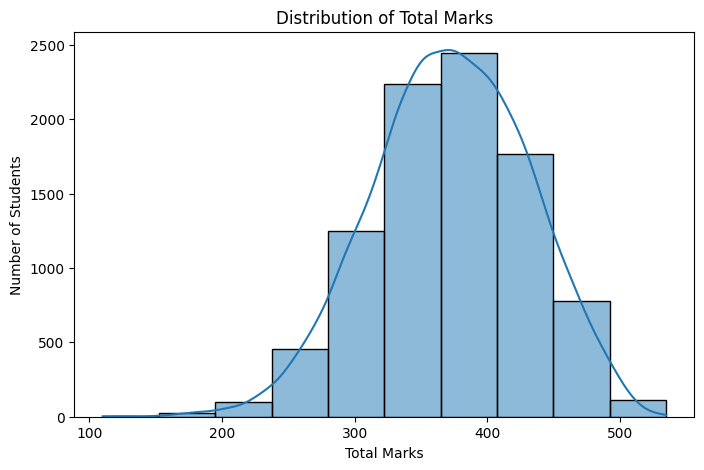

In [5]:
plt.figure(figsize=(8,5))
sns.histplot(df['Total Marks'], bins=10, kde=True)
plt.title("Distribution of Total Marks")
plt.xlabel("Total Marks")
plt.ylabel("Number of Students")
plt.show()

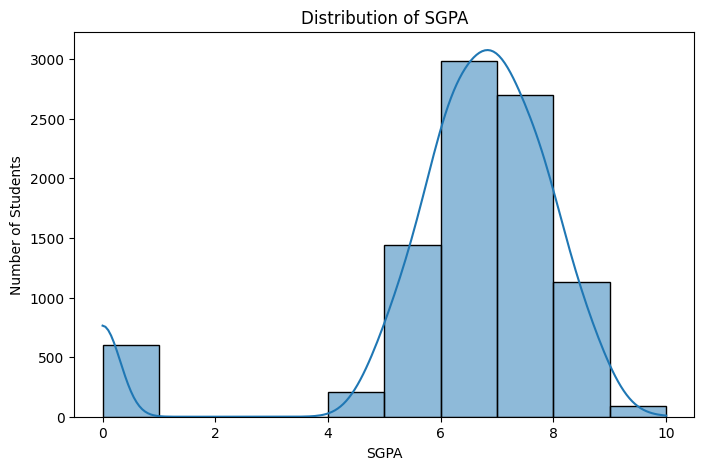

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(df['SGPA'], bins=10, kde=True)
plt.title("Distribution of SGPA")
plt.xlabel("SGPA")
plt.ylabel("Number of Students")
plt.show()

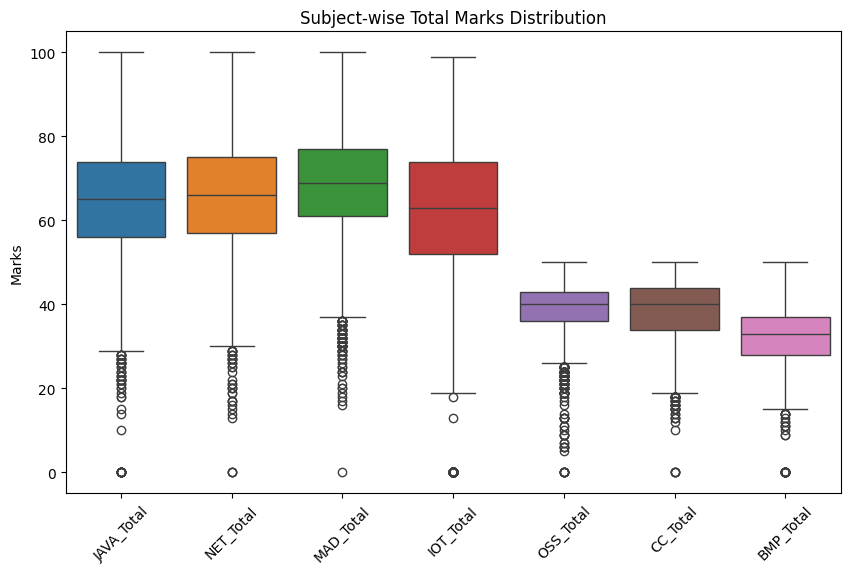

In [7]:
subject_totals = [
    'JAVA_Total',
    'NET_Total',
    'MAD_Total',
    'IOT_Total',
    'OSS_Total',
    'CC_Total',
    'BMP_Total'
]

plt.figure(figsize=(10,6))
sns.boxplot(data=df[subject_totals])

plt.title("Subject-wise Total Marks Distribution")
plt.ylabel("Marks")
plt.xticks(rotation=45)

plt.show()

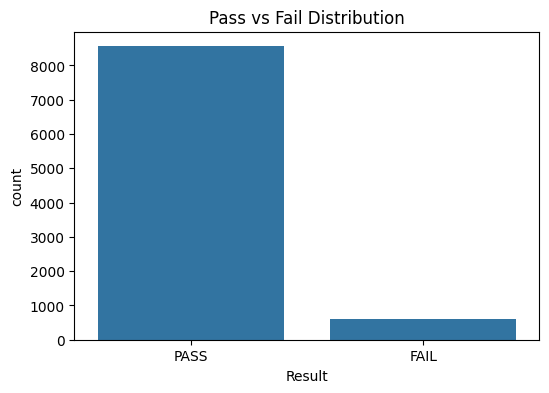

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(x='Result', data=df)
plt.title("Pass vs Fail Distribution")
plt.show()

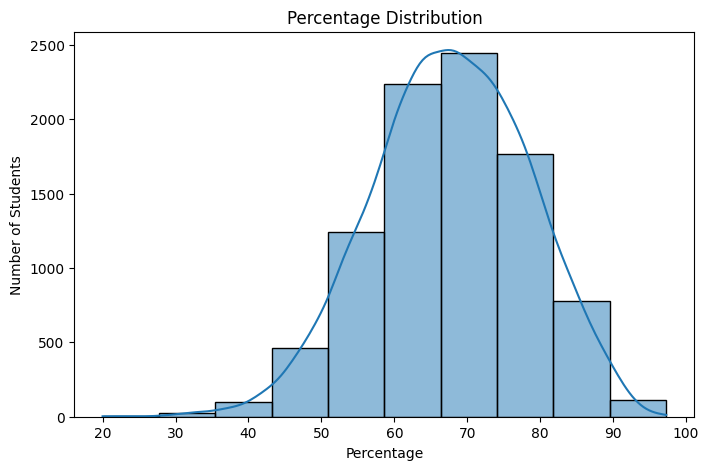

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df['Percentage'], bins=10, kde=True)
plt.title("Percentage Distribution")
plt.xlabel("Percentage")
plt.ylabel("Number of Students")
plt.show()

Subject-wise Failure Count:
JAVA: 86
NET: 54
MAD: 52
IOT: 332
OSS: 1195
CC: 25
BMP: 74


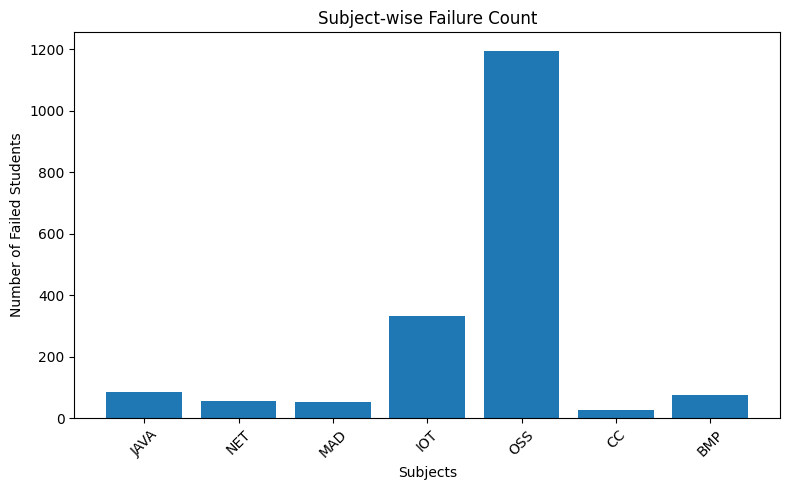

In [10]:
import matplotlib.pyplot as plt

# Subject-wise Failure Count based on Passing Criteria
failure_counts = {
    'JAVA': (df['JAVA_Total'] < 33).sum(),
    'NET': (df['NET_Total'] < 33).sum(),
    'MAD': (df['MAD_Total'] < 33).sum(),
    'IOT': (df['IOT_Total'] < 33).sum(),
    'OSS': (df['OSS_Total'] < 33).sum(),
    'CC': (df['CC_Total'] < 18).sum(),
    'BMP': (df['BMP_Total'] < 18).sum(),
}

# Print Failure Counts
print("Subject-wise Failure Count:")
for subject, count in failure_counts.items():
    print(f"{subject}: {count}")

# Plot Bar Graph
plt.figure(figsize=(8,5))
plt.bar(failure_counts.keys(), failure_counts.values())
plt.title("Subject-wise Failure Count")
plt.xlabel("Subjects")
plt.ylabel("Number of Failed Students")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Bivariate


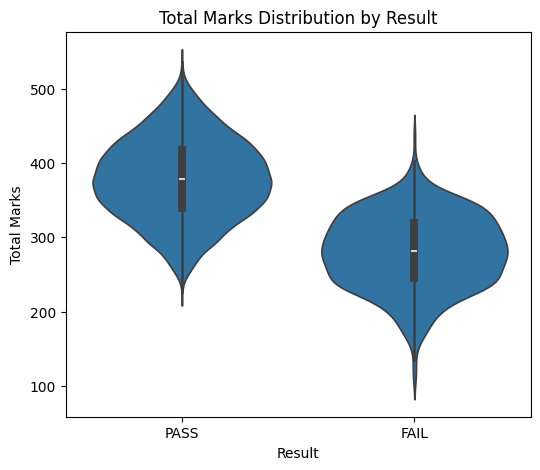

In [11]:
plt.figure(figsize=(6,5))
sns.violinplot(x='Result', y='Total Marks', data=df)
plt.title("Total Marks Distribution by Result")
plt.show()

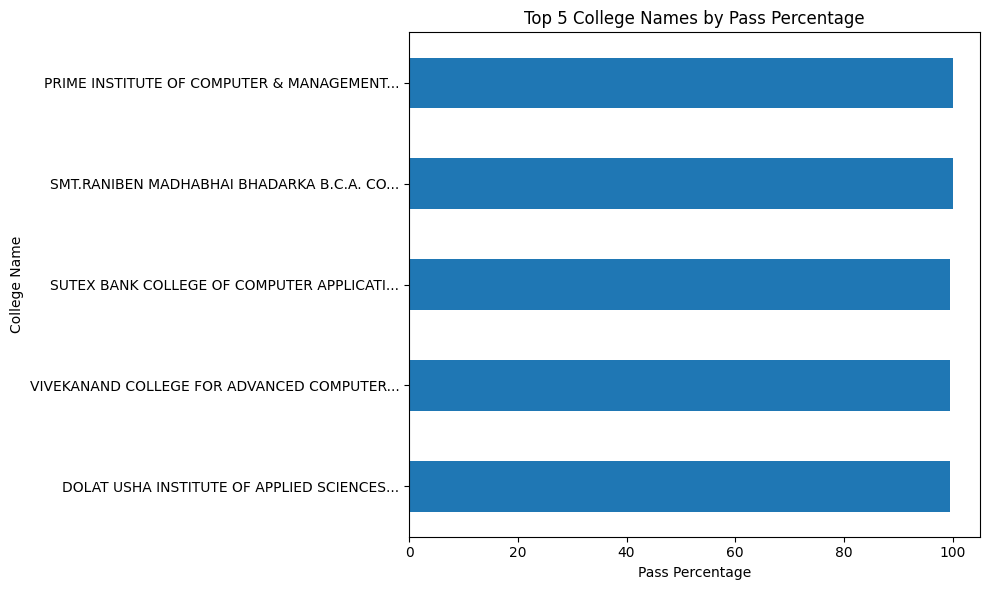

In [12]:
# Calculate pass percentage by college
pass_percentage = df.groupby('College Name')['Result'].apply(
    lambda x: (x == 'PASS').mean() * 100
).sort_values(ascending=False)

top5 = pass_percentage.head(5)

# Function to shorten college names (max 25 characters)
def shorten_name(name):
    return name if len(name) <= 25 else name[:40] + "..."

# Apply name shortening
top5.index = top5.index.map(shorten_name)

# Plot horizontal bar chart
plt.figure(figsize=(10, 6))

top5.sort_values().plot(kind='barh')

plt.title("Top 5 College Names by Pass Percentage")
plt.xlabel("Pass Percentage")
plt.ylabel("College Name")

plt.tight_layout()
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_10932\3535080898.py:9: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


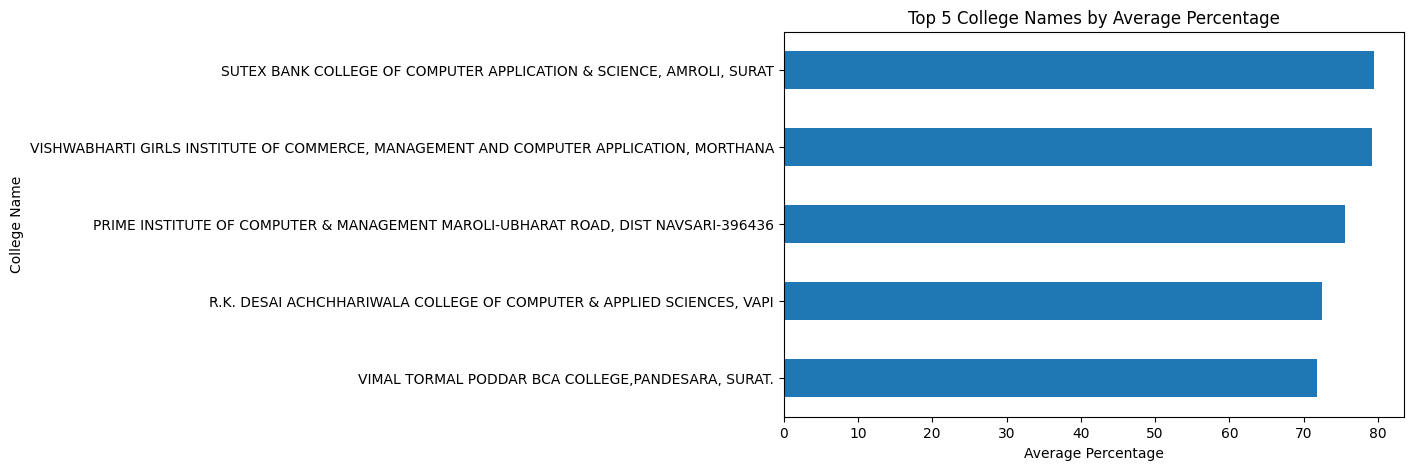

In [13]:
college_avg = df.groupby('College Name')['Percentage'].mean().sort_values(ascending=False)

top5 = college_avg.head(5)

plt.figure(figsize=(8,5))
top5.sort_values().plot(kind='barh')
plt.title("Top 5 College Names by Average Percentage")
plt.xlabel("Average Percentage")
plt.tight_layout()
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_10932\3535080898.py:9: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


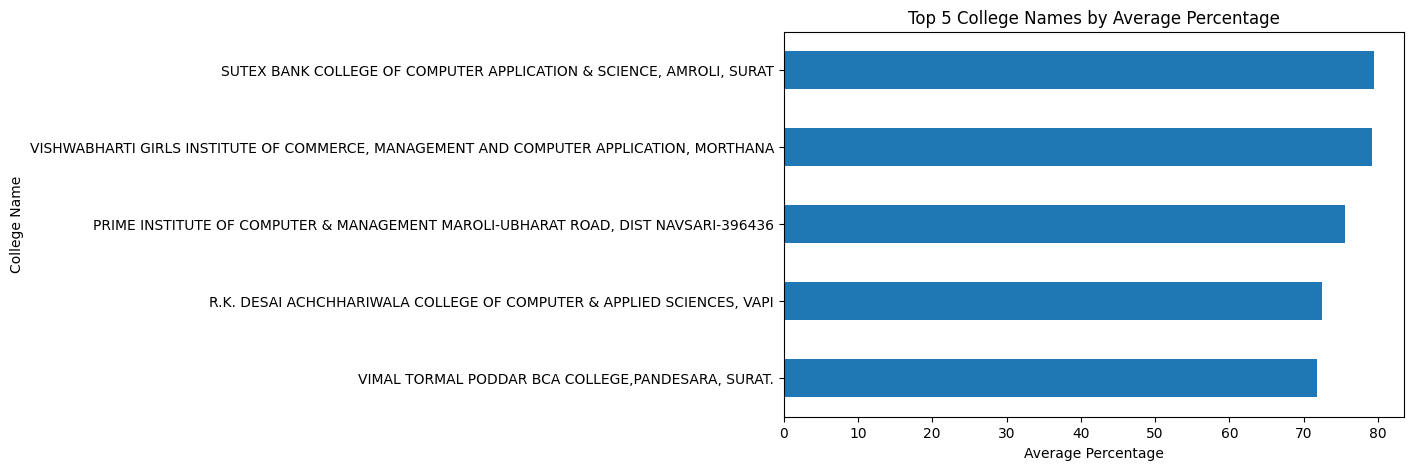

In [14]:
college_avg = df.groupby('College Name')['Percentage'].mean().sort_values(ascending=False)

top5 = college_avg.head(5)

plt.figure(figsize=(8,5))
top5.sort_values().plot(kind='barh')
plt.title("Top 5 College Names by Average Percentage")
plt.xlabel("Average Percentage")
plt.tight_layout()
plt.show()

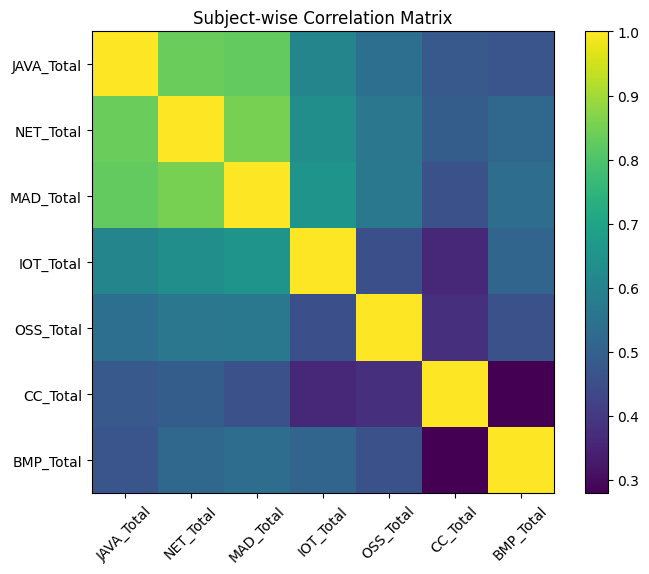

In [15]:
subject_cols = [
    'JAVA_Total',
    'NET_Total',
    'MAD_Total',
    'IOT_Total',
    'OSS_Total',
    'CC_Total',
    'BMP_Total'
]

corr_matrix = df[subject_cols].corr()

plt.figure(figsize=(8,6))
plt.imshow(corr_matrix)

plt.xticks(range(len(subject_cols)), subject_cols, rotation=45)
plt.yticks(range(len(subject_cols)), subject_cols)

plt.title("Subject-wise Correlation Matrix")
plt.colorbar()

plt.show()

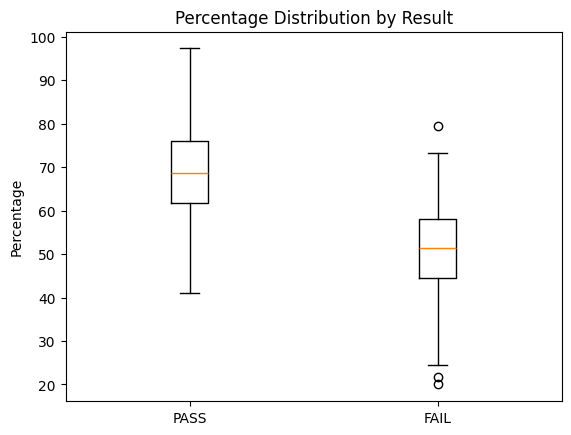

In [16]:
pass_percent = df[df['Result'] == 'PASS']['Percentage']
fail_percent = df[df['Result'] != 'PASS']['Percentage']

plt.boxplot([pass_percent, fail_percent], labels=['PASS', 'FAIL'])
plt.title("Percentage Distribution by Result")
plt.ylabel("Percentage")
plt.show()

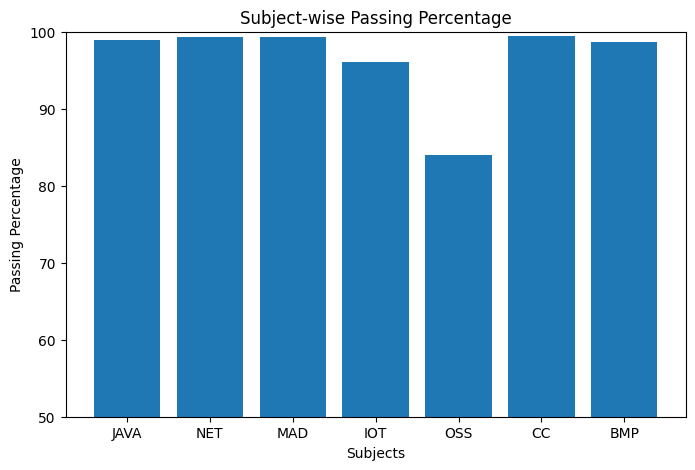

In [17]:
Passing_percentage = {
    'JAVA': (df['JAVA_Total'] > 33).mean() * 100,
    'NET': (df['NET_Total'] > 33).mean() * 100,
    'MAD': (df['MAD_Total'] > 33).mean() * 100,
    'IOT': (df['IOT_Total'] > 33).mean() * 100,
    'OSS': (df['OSS_Total'] > 33).mean() * 100,
    'CC': (df['CC_Total'] > 18).mean() * 100,
    'BMP': (df['BMP_Total'] > 18).mean() * 100
}

plt.figure(figsize=(8,5))
plt.bar(Passing_percentage.keys(), Passing_percentage.values())
plt.ylim(50,100)
plt.title("Subject-wise Passing Percentage")
plt.xlabel("Subjects")
plt.ylabel("Passing Percentage")

plt.show()

## Multivariate

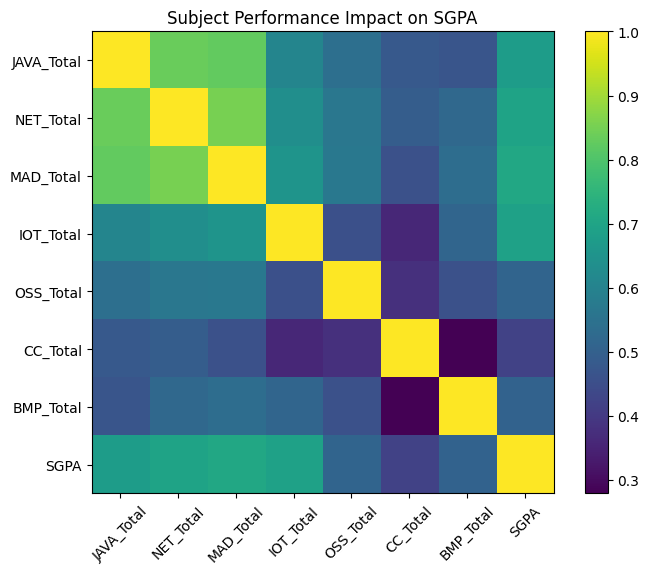

In [18]:
subject_cols = [
    'JAVA_Total',
    'NET_Total',
    'MAD_Total',
    'IOT_Total',
    'OSS_Total',
    'CC_Total',
    'BMP_Total'
]

combined_corr = df[subject_cols + ['SGPA']].corr()

plt.figure(figsize=(8,6))
plt.imshow(combined_corr)

plt.xticks(range(len(subject_cols)+1), subject_cols + ['SGPA'], rotation=45)
plt.yticks(range(len(subject_cols)+1), subject_cols + ['SGPA'])

plt.title("Subject Performance Impact on SGPA")
plt.colorbar()

plt.show()

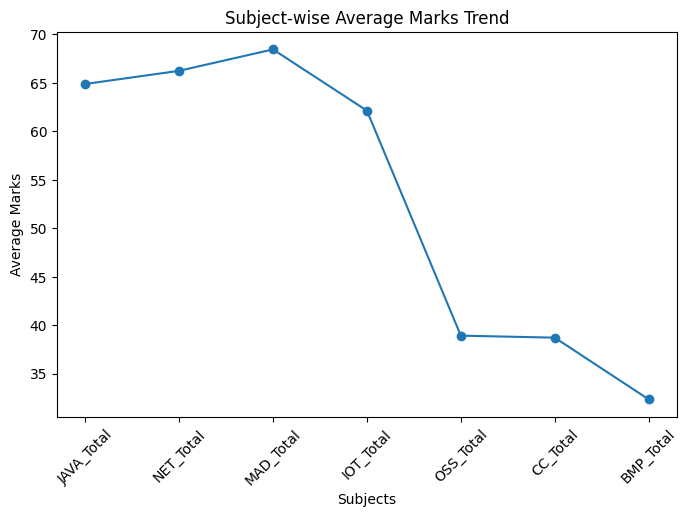

In [19]:
import matplotlib.pyplot as plt

subject_cols = [
    'JAVA_Total',
    'NET_Total',
    'MAD_Total',
    'IOT_Total',
    'OSS_Total',
    'CC_Total',
    'BMP_Total'
]

subject_avg = df[subject_cols].mean()

plt.figure(figsize=(8,5))
plt.plot(subject_cols, subject_avg, marker='o')

plt.title("Subject-wise Average Marks Trend")
plt.xlabel("Subjects")
plt.ylabel("Average Marks")

plt.xticks(rotation=45)

plt.show()

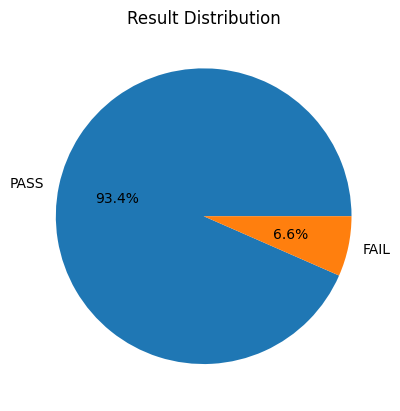

In [20]:
result_counts = df['Result'].value_counts()

plt.figure()
plt.pie(result_counts, labels=result_counts.index, autopct='%1.1f%%')
plt.title("Result Distribution")
plt.show()

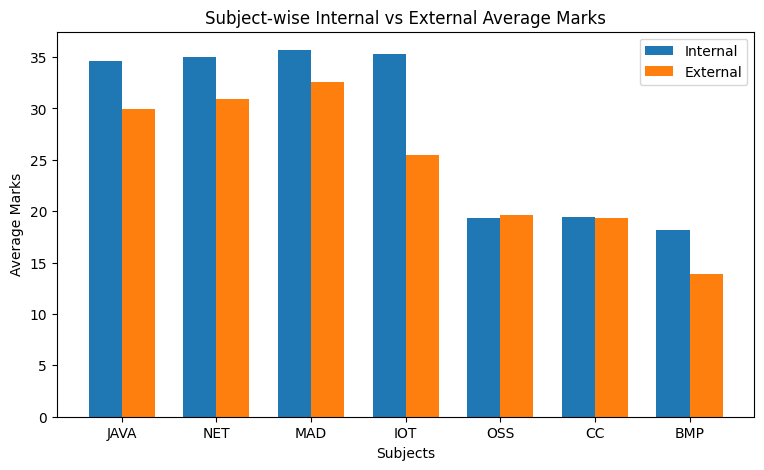

In [21]:
import numpy as np
import matplotlib.pyplot as plt

subjects = ['JAVA','NET','MAD','IOT','OSS','CC','BMP']

internal_avg = [
df['JAVA_Int'].mean(),
df['NET_Int'].mean(),
df['MAD_Int'].mean(),
df['IOT_Int'].mean(),
df['OSS_Int'].mean(),
df['CC_Int'].mean(),
df['BMP_Int'].mean()
]

external_avg = [
df['JAVA_Ext'].mean(),
df['NET_Ext'].mean(),
df['MAD_Ext'].mean(),
df['IOT_Ext'].mean(),
df['OSS_Ext'].mean(),
df['CC_Ext'].mean(),
df['BMP_Ext'].mean()
]

x = np.arange(len(subjects))
width = 0.35

plt.figure(figsize=(9,5))

plt.bar(x-width/2, internal_avg, width, label='Internal')
plt.bar(x+width/2, external_avg, width, label='External')

plt.xticks(x, subjects)

plt.title("Subject-wise Internal vs External Average Marks")
plt.xlabel("Subjects")
plt.ylabel("Average Marks")

plt.legend()

plt.show()

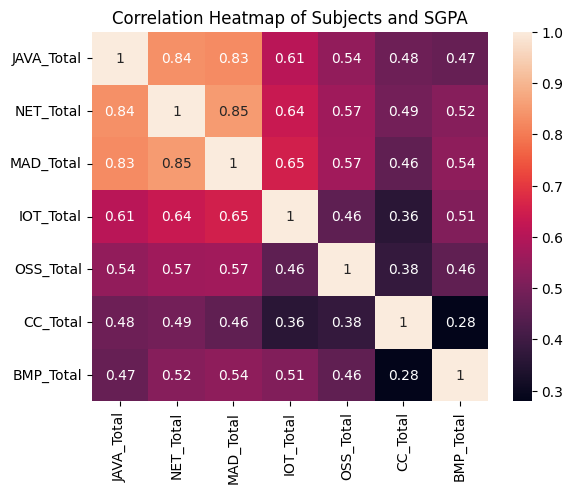

In [22]:
import seaborn as sns

cols = ['JAVA_Total', 'NET_Total','MAD_Total','IOT_Total','OSS_Total','CC_Total','BMP_Total']

plt.figure()
sns.heatmap(df[cols].corr(), annot=True)

plt.title("Correlation Heatmap of Subjects and SGPA")
plt.show()

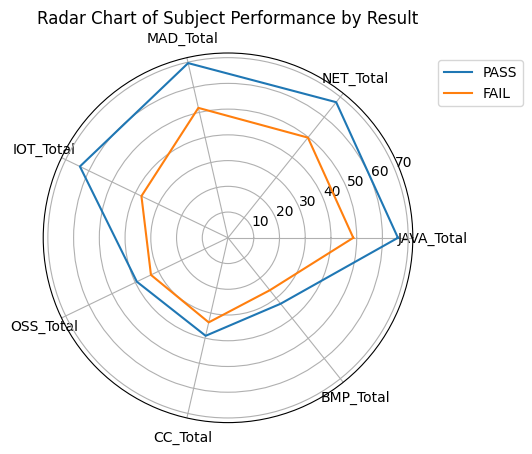

In [23]:
import numpy as np
import matplotlib.pyplot as plt

subjects = ['JAVA_Total', 'NET_Total','MAD_Total','IOT_Total','OSS_Total','CC_Total','BMP_Total']

pass_avg = df[df['Result']=='PASS'][subjects].mean().values
fail_avg = df[df['Result']!='PASS'][subjects].mean().values

angles = np.linspace(0,2*np.pi,len(subjects),endpoint=False)

pass_avg = np.concatenate((pass_avg,[pass_avg[0]]))
fail_avg = np.concatenate((fail_avg,[fail_avg[0]]))
angles = np.concatenate((angles,[angles[0]]))

fig = plt.figure()
ax = fig.add_subplot(111, polar=True)

ax.plot(angles, pass_avg, label='PASS')
ax.plot(angles, fail_avg, label='FAIL')

ax.set_xticks(angles[:-1])
ax.set_xticklabels(subjects)

plt.title("Radar Chart of Subject Performance by Result")

# Move legend outside
plt.legend(loc='upper left', bbox_to_anchor=(1.05,1))

plt.show()

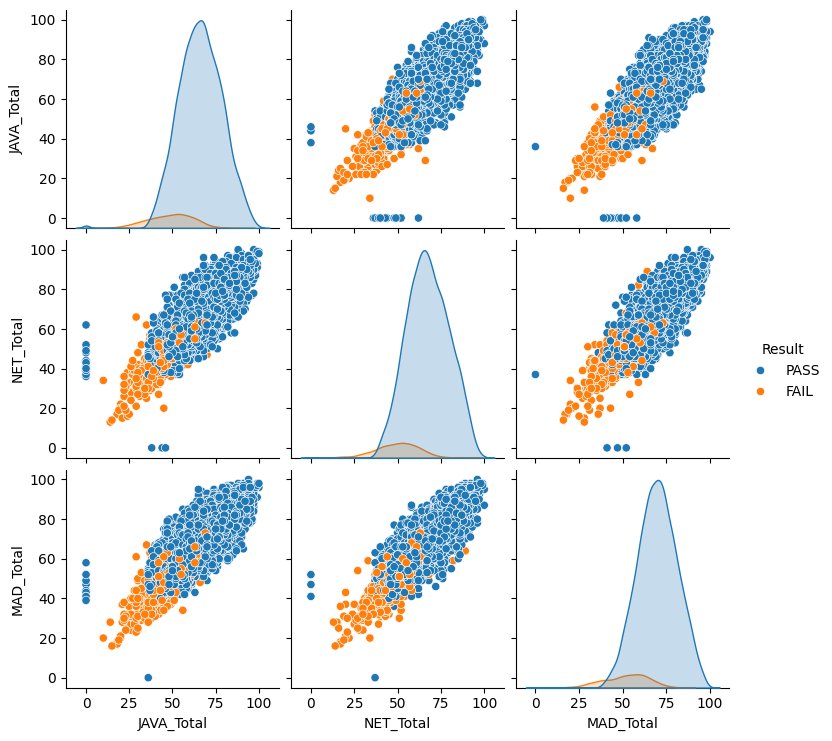

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(
    df[['JAVA_Total','NET_Total','MAD_Total','Result']],
    hue='Result'
)

plt.show()

In [25]:
import sweetviz as sv


my_report = sv.analyze(df)
my_report.show_html()

                                             |          | [  0%]   00:00 -> (? left)

Report SWEETVIZ_REPORT.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.
